# SegFormer-B2 with Agentic Training Framework for Landslide Segmentation

## Overview

This implementation presents an **Agentic SegFormer-B2 Framework** for landslide segmentation using multi-temporal InSAR data. The objective is to accurately identify landslide regions while improving training stability and reducing manual hyperparameter tuning.

The framework combines:

* SegFormer-B2 Transformer Architecture
* Phase Decomposition (Cosine and Sine Representation)
* Hybrid BCE + Dice Loss
* Agentic Training Strategy
* Adaptive Learning Rate Control
* Dynamic Loss Weight Adjustment

---

## Dataset Preparation

The dataset consists of:

* Coherence Images
* Phase Images
* Ground Truth Segmentation Masks

To better represent phase information, the original phase values were transformed into:

```python
Cos(Phase)
Sin(Phase)
```

The final input channels are:

```python
[Coherence, Cos(Phase), Sin(Phase)]
```

This representation helps preserve periodic phase information while reducing phase discontinuity issues.

---

## Data Augmentation

To improve model generalization, the following augmentation techniques were applied during training:

* Horizontal Flip
* Vertical Flip
* Random Rotation (90°)
* Transpose Transformation

These augmentations increase data diversity and help the model learn robust spatial patterns.

---

## Dataset Split

The dataset contains **13,230 samples**.

| Dataset Split | Samples |
| ------------- | ------- |
| Training      | 9,261   |
| Validation    | 1,984   |
| Testing       | 1,985   |

Split Ratio:

```python
Training   = 70%
Validation = 15%
Testing    = 15%
```

---

## Model Architecture

### SegFormer-B2

The segmentation backbone used is:

```python
nvidia/segformer-b2-finetuned-ade-512-512
```

### Additional Modifications

* Binary Segmentation Head
* Dropout Layer (0.10)
* Bilinear Upsampling
* Output Resolution: 100 × 100

The model predicts landslide and non-landslide regions at pixel level.

---

## Hybrid Loss Function

Instead of relying on a single loss function, a hybrid loss strategy was implemented.

### Binary Cross Entropy Loss

Used for pixel-wise classification.

### Dice Loss

Used for region overlap optimization.

### Final Hybrid Loss

```python
Hybrid Loss =
0.50 × BCE Loss +
0.50 × Dice Loss
```

### Benefits

* Improves pixel classification accuracy
* Enhances segmentation overlap quality
* Handles class imbalance more effectively

---

## Agentic Training Framework

A lightweight training agent was introduced to monitor model performance and adapt training automatically.

The agent continuously analyzes:

* Validation Loss
* Validation IoU
* Validation Dice Score

### Agent Actions

#### 1. Learning Rate Reduction

When validation loss increases:

```python
Learning Rate = Learning Rate × 0.8
```

#### 2. Dice Weight Adjustment

When IoU performance decreases:

```python
Dice Weight ↑
BCE Weight ↓
```

This encourages better region-level segmentation.

#### 3. Threshold Adjustment

When recall drops below:

```python
Recall < 0.60
```

Prediction threshold becomes:

```python
Threshold = 0.45
```

This helps recover missed landslide pixels.

---

## Optimization Strategy

| Parameter               | Value             |
| ----------------------- | ----------------- |
| Optimizer               | AdamW             |
| Learning Rate           | 1e-4              |
| Weight Decay            | 1e-4              |
| Scheduler               | ReduceLROnPlateau |
| Epochs                  | 200               |
| Early Stopping Patience | 25                |
| Gradient Clipping       | 1.0               |

---

## Training Behaviour

During training, the model demonstrated:

* Stable convergence
* Continuous reduction in validation loss
* Consistent improvement in Dice Score
* Increasing IoU performance
* Effective adaptation through agent decisions

The training agent remained mostly in **Continue Mode**, indicating smooth optimization without severe performance degradation.

---
#  Results Summary

The proposed **Agentic SegFormer-B2 Framework** achieved strong and stable performance for landslide segmentation using multi-temporal InSAR data.

### Best Validation Results

| Metric | Value |
|----------|----------|
| Accuracy | **98.60%** |
| Precision | **82.17%** |
| Recall | **80.56%** |
| Dice Score | **80.70%** |
| IoU Score | **68.41%** |
| Validation Loss | **0.1342** |

---

## Evaluation Metrics

The model was evaluated using:

### Accuracy

Measures overall pixel classification performance.

### Precision

Measures correctness of predicted landslide pixels.

### Recall

Measures ability to detect actual landslide regions.

### F1 Score

Balances precision and recall.

### Dice Score

Measures segmentation overlap quality.

### IoU (Intersection over Union)

Measures region-level agreement between prediction and ground truth masks.

---

## Key Findings

 SegFormer-B2 effectively learned landslide patterns from InSAR imagery.

 Phase decomposition improved representation of phase information.

 Hybrid BCE + Dice Loss produced more balanced optimization.

 Agentic monitoring reduced the need for manual hyperparameter tuning.

 Validation Dice Score improved steadily throughout training.

 IoU performance showed consistent growth.

 The framework maintained stable learning behaviour across epochs.

---

## Advantages of the Proposed Framework

### Transformer-Based Feature Extraction

Captures long-range spatial dependencies more effectively than traditional CNN architectures.

### Intelligent Training Adaptation

Automatically responds to performance changes during training.

### Improved Segmentation Quality

Hybrid loss optimization improves boundary localization and region overlap.

### Reduced Manual Intervention

Agentic decisions minimize the need for frequent hyperparameter adjustments.

---

## Conclusion

The proposed **Agentic SegFormer-B2 Framework** successfully integrates Transformer-based semantic segmentation with intelligent training adaptation for landslide detection.

By combining phase decomposition, hybrid loss optimization, adaptive thresholding, and automated training decisions, the framework achieves stable convergence and improved segmentation performance. This approach demonstrates the potential of agent-assisted deep learning systems for remote sensing and geospatial image analysis tasks.


#  Complete Agentic SegFormer-B2 Training Pipeline

```text
┌──────────────────────────────────────────┐
│ Multi-Temporal InSAR Dataset             │
│ (6 Days, 12 Days, 18 Days)               │
└──────────────────────────────────────────┘
                    │
                    ▼
┌──────────────────────────────────────────┐
│ Data Collection & Organization           │
│ • Coherence Images                       │
│ • Phase Images                           │
│ • Ground Truth Masks                     │
└──────────────────────────────────────────┘
                    │
                    ▼
┌──────────────────────────────────────────┐
│ Phase Decomposition Module               │
│                                          │
│ Phase → Cos(Phase)                       │
│ Phase → Sin(Phase)                       │
└──────────────────────────────────────────┘
                    │
                    ▼
┌──────────────────────────────────────────┐
│ Input Construction                       │
│                                          │
│ Channel 1 → Coherence                    │
│ Channel 2 → Cos(Phase)                   │
│ Channel 3 → Sin(Phase)                   │
└──────────────────────────────────────────┘
                    │
                    ▼
┌──────────────────────────────────────────┐
│ Channel-wise Normalization               │
│ Mean = 0                                 │
│ Std = 1                                  │
└──────────────────────────────────────────┘
                    │
                    ▼
┌──────────────────────────────────────────┐
│ Data Augmentation                        │
│                                          │
│ • Horizontal Flip                        │
│ • Vertical Flip                          │
│ • RandomRotate90                         │
│ • Transpose                              │
└──────────────────────────────────────────┘
                    │
                    ▼
══════════════════════════════════════════════
         SEGFORMER-B2 ARCHITECTURE
══════════════════════════════════════════════

                    │
                    ▼
┌──────────────────────────────────────────┐
│ Transformer Encoder                      │
│                                          │
│ • Multi-Head Attention                   │
│ • Global Context Learning                │
│ • Hierarchical Features                  │
└──────────────────────────────────────────┘
                    │
                    ▼
┌──────────────────────────────────────────┐
│ Multi-Scale Feature Fusion               │
│                                          │
│ • Stage 1 Features                       │
│ • Stage 2 Features                       │
│ • Stage 3 Features                       │
│ • Stage 4 Features                       │
└──────────────────────────────────────────┘
                    │
                    ▼
┌──────────────────────────────────────────┐
│ SegFormer Decoder Head                   │
│                                          │
│ Binary Segmentation Output               │
└──────────────────────────────────────────┘
                    │
                    ▼
┌──────────────────────────────────────────┐
│ Decoder Logits                           │
└──────────────────────────────────────────┘
                    │
                    ▼
┌──────────────────────────────────────────┐
│ Dropout Layer (p = 0.10)                 │
│                                          │
│ Regularization                           │
│ Overfitting Prevention                   │
└──────────────────────────────────────────┘
                    │
                    ▼
┌──────────────────────────────────────────┐
│ Bilinear Upsampling                      │
│ Output Size: 100 × 100                   │
└──────────────────────────────────────────┘
                    │
                    ▼
┌──────────────────────────────────────────┐
│ Predicted Landslide Mask                 │
└──────────────────────────────────────────┘
                    │
                    ▼
══════════════════════════════════════════════
           HYBRID LOSS ENGINE
══════════════════════════════════════════════

                    │
                    ▼
┌──────────────────────────────────────────┐
│ BCE Loss                                 │
│ Pixel-Level Classification               │
└──────────────────────────────────────────┘
                    │
                    ├────────────┐
                    ▼            │
┌──────────────────────────────────────────┐
│ Dice Loss                                │
│ Region Overlap Optimization              │
└──────────────────────────────────────────┘
                    │            ▲
                    └─────┬──────┘
                          │
                          ▼
┌──────────────────────────────────────────┐
│ Hybrid Loss                              │
│                                          │
│ 0.50 × BCE                               │
│ +                                        │
│ 0.50 × Dice                              │
└──────────────────────────────────────────┘
                    │
                    ▼
══════════════════════════════════════════════
          AGENTIC TRAINING LAYER
══════════════════════════════════════════════

                    │
                    ▼
┌──────────────────────────────────────────┐
│ Agent Monitoring System                  │
│                                          │
│ Tracks Last 5 Epochs                     │
│                                          │
│ • Validation Loss                        │
│ • Validation IoU                         │
│ • Validation Dice                        │
│ • Recall                                 │
└──────────────────────────────────────────┘
                    │
                    ▼

        ┌───────────────────────┐
        │ Agent Decision Engine │
        └───────────────────────┘
                    │
        ┌───────────┼───────────┐
        │           │           │
        ▼           ▼           ▼

┌──────────────┐ ┌──────────────┐ ┌──────────────┐
│ Reduce LR    │ │ Increase     │ │ Threshold    │
│              │ │ Dice Weight  │ │ Adjustment   │
└──────────────┘ └──────────────┘ └──────────────┘

Condition 1:
Val Loss ↑

Action:
LR = LR × 0.8


Condition 2:
Val IoU ↓

Action:
Dice Weight += 0.05
BCE Weight = 1 - Dice Weight


Condition 3:
Recall < 0.60

Action:
Threshold = 0.45


Condition 4:
Stable Performance

Action:
Continue Training

                    │
                    ▼
══════════════════════════════════════════════
        OPTIMIZATION & STABILIZATION
══════════════════════════════════════════════

┌──────────────────────────────────────────┐
│ AdamW Optimizer                          │
│ LR = 1e-4                                │
│ Weight Decay = 1e-4                      │
└──────────────────────────────────────────┘
                    │
                    ▼
┌──────────────────────────────────────────┐
│ ReduceLROnPlateau Scheduler              │
└──────────────────────────────────────────┘
                    │
                    ▼
┌──────────────────────────────────────────┐
│ Gradient Clipping                        │
│ Max Norm = 1.0                           │
└──────────────────────────────────────────┘
                    │
                    ▼
┌──────────────────────────────────────────┐
│ Early Stopping                           │
│ Patience = 25 Epochs                     │
└──────────────────────────────────────────┘
                    │
                    ▼
══════════════════════════════════════════════
              EVALUATION
══════════════════════════════════════════════

┌──────────────────────────────────────────┐
│ Accuracy                                 │
│ Precision                                │
│ Recall                                   │
│ F1 Score                                 │
│ Dice Score                               │
│ IoU Score                                │
└──────────────────────────────────────────┘
                    │
                    ▼
┌──────────────────────────────────────────┐
│ Final Landslide Segmentation             │
│ Results & Performance Analysis           │
└──────────────────────────────────────────┘
```

##  One-Line Workflow

```text
Multi-Temporal InSAR Data
        ↓
Phase Decomposition
        ↓
3-Channel Input Generation
        ↓
Normalization
        ↓
Data Augmentation
        ↓
SegFormer-B2 Transformer Encoder
        ↓
Multi-Scale Feature Fusion
        ↓
SegFormer Decoder
        ↓
Dropout (0.10)
        ↓
Upsampling
        ↓
Predicted Mask
        ↓
Hybrid BCE + Dice Loss
        ↓
Agentic Monitoring & Decision Engine
        ↓
Adaptive Learning Rate / Dice Weight / Threshold
        ↓
AdamW Optimization
        ↓
Evaluation Metrics
        ↓
Final Landslide Segmentation
```

In [127]:
import os
import random

import cv2

import tifffile as tiff

import numpy as np

import matplotlib.pyplot as plt

import albumentations as A
from torch.utils.data import Dataset

from collections import deque

import torch

import torch.nn as nn

import torch.nn.functional as F
from torch.utils.data import random_split

from torch.utils.data import Dataset

from torch.utils.data import DataLoader

from transformers import (

    SegformerForSemanticSegmentation

)

from sklearn.metrics import (

    confusion_matrix,

    ConfusionMatrixDisplay

)

In [128]:
device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else

    "cpu"

)

print(

    "Device:",

    device

)

Device: cuda


In [129]:
root_dir = "/kaggle/input/datasets/rishikeshgopal45/landslide-insar-isslide/ReadyToBeUsedDataset"

print(

    "Dataset Path:",

    root_dir

)

Dataset Path: /kaggle/input/datasets/rishikeshgopal45/landslide-insar-isslide/ReadyToBeUsedDataset


In [130]:
train_transform = A.Compose([

    A.HorizontalFlip(

        p=0.5

    ),

    A.VerticalFlip(

        p=0.5

    ),

    A.RandomRotate90(

        p=1.0

    ),

    A.Transpose(

        p=0.5

    )

])

val_transform = None

test_transform = None

In [131]:
class SegFormerDataset(Dataset):

    def __init__(

        self,

        root_dir,

        regions=None,

        transform=None

    ):

        self.samples = []

        self.transform = transform

        temporal_folders = [

            "6days",

            "12days",

            "18days"

        ]

        for temporal in temporal_folders:

            temporal_path = os.path.join(

                root_dir,

                temporal

            )

            for region in sorted(

                os.listdir(

                    temporal_path

                )

            ):

                if (

                    regions is not None

                    and

                    region not in regions

                ):

                    continue

                region_path = os.path.join(

                    temporal_path,

                    region

                )

                folders = os.listdir(

                    region_path

                )

                for folder in folders:

                    if folder == "Segmentations":

                        continue

                    coh_path = os.path.join(

                        region_path,

                        folder,

                        "coherence"

                    )

                    phase_path = os.path.join(

                        region_path,

                        folder,

                        "phase"

                    )

                    mask_path = os.path.join(

                        region_path,

                        "Segmentations",

                        folder

                    )

                    if not (

                        os.path.exists(coh_path)

                        and

                        os.path.exists(phase_path)

                        and

                        os.path.exists(mask_path)

                    ):

                        continue

                    files = sorted(

                        os.listdir(

                            coh_path

                        )

                    )

                    for file in files:

                        if file.endswith(

                            ".tif"

                        ):

                            self.samples.append(

                                (

                                    os.path.join(

                                        coh_path,

                                        file

                                    ),

                                    os.path.join(

                                        phase_path,

                                        file

                                    ),

                                    os.path.join(

                                        mask_path,

                                        file

                                    )

                                )

                            )

        print(

            "Samples:",

            len(self.samples)

        )

    def __len__(self):

        return len(

            self.samples

        )

    def __getitem__(

        self,

        idx

    ):

        coh_file, phase_file, mask_file = self.samples[idx]

        coherence = tiff.imread(

            coh_file

        ).astype(

            np.float32

        )

        phase = tiff.imread(

            phase_file

        ).astype(

            np.float32

        )

        mask = tiff.imread(

            mask_file

        ).astype(

            np.float32

        )

        cos_phase = np.cos(

            phase

        )

        sin_phase = np.sin(

            phase

        )

        image = np.stack(

            [

                coherence,

                cos_phase,

                sin_phase

            ],

            axis=-1

        )

        if self.transform is not None:

            transformed = self.transform(

                image=image,

                mask=mask

            )

            image = transformed["image"]

            mask = transformed["mask"]

        image = np.transpose(

            image,

            (2,0,1)

        )

        for c in range(

            image.shape[0]

        ):

            image[c] = (

                image[c]

                -

                image[c].mean()

            ) / (

                image[c].std()

                +

                1e-8

            )

        mask = np.expand_dims(

            mask,

            axis=0

        )

        return (

            torch.tensor(

                image,

                dtype=torch.float32

            ),

            torch.tensor(

                mask,

                dtype=torch.float32

            )

        )

In [132]:
full_dataset = SegFormerDataset(

    root_dir,

    regions=None,

    transform=None

)

total_size = len(

    full_dataset

)

train_size = int(

    0.70 * total_size

)

val_size = int(

    0.15 * total_size

)

test_size = (

    total_size

    -

    train_size

    -

    val_size

)

train_subset, val_subset, test_subset = random_split(

    full_dataset,

    [

        train_size,

        val_size,

        test_size

    ],

    generator=torch.Generator().manual_seed(
        42
    )

)

train_dataset = torch.utils.data.Subset(

    SegFormerDataset(

        root_dir,

        regions=None,

        transform=train_transform

    ),

    train_subset.indices

)

val_dataset = torch.utils.data.Subset(

    SegFormerDataset(

        root_dir,

        regions=None,

        transform=None

    ),

    val_subset.indices

)

test_dataset = torch.utils.data.Subset(

    SegFormerDataset(

        root_dir,

        regions=None,

        transform=None

    ),

    test_subset.indices

)

print(

    "Train Samples:",

    len(train_dataset)

)

print(

    "Validation Samples:",

    len(val_dataset)

)

print(

    "Test Samples:",

    len(test_dataset)

)

Samples: 13230
Samples: 13230
Samples: 13230
Samples: 13230
Train Samples: 9261
Validation Samples: 1984
Test Samples: 1985


In [133]:
train_loader = DataLoader(

    train_dataset,

    batch_size=8,

    shuffle=True,

    num_workers=2

)

val_loader = DataLoader(

    val_dataset,

    batch_size=8,

    shuffle=False,

    num_workers=2

)

test_loader = DataLoader(

    test_dataset,

    batch_size=8,

    shuffle=False,

    num_workers=2

)

print("\n")

print(

    "Train Samples:",

    len(train_dataset)

)

print(

    "Validation Samples:",

    len(val_dataset)

)

print(

    "Test Samples:",

    len(test_dataset)

)



Train Samples: 9261
Validation Samples: 1984
Test Samples: 1985


In [134]:
class SegFormerModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.segformer = SegformerForSemanticSegmentation.from_pretrained(

            "nvidia/segformer-b2-finetuned-ade-512-512",

            num_labels=1,

            ignore_mismatched_sizes=True

        )

        self.dropout = nn.Dropout2d(
            p=0.10
        )

    def forward(self, x):

        outputs = self.segformer(
            pixel_values=x
        )

        logits = outputs.logits

        logits = self.dropout(
            logits
        )

        logits = F.interpolate(

            logits,

            size=(100,100),

            mode="bilinear",

            align_corners=False

        )

        return logits


model = SegFormerModel().to(device)

print("Model Loaded Successfully")

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([1, 768, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([1])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Model Loaded Successfully


In [135]:
sample_batch = next(
    iter(train_loader)
)

images, masks = sample_batch

images = images.to(device)

with torch.no_grad():

    outputs = model(images)

print(

    "Input Shape :",

    images.shape

)

print(

    "Output Shape:",

    outputs.shape

)

Input Shape : torch.Size([8, 3, 100, 100])
Output Shape: torch.Size([8, 1, 100, 100])


In [136]:
class TrainingAgent:

    def __init__(self):

        self.best_iou = 0

        self.best_dice = 0

        self.history = deque(
            maxlen=5
        )

    def analyze(

        self,

        val_loss,

        val_iou,

        val_dice,

        optimizer

    ):

        self.history.append(

            (

                val_loss,

                val_iou,

                val_dice

            )

        )

        if len(self.history) < 5:

            return "warmup"

        losses = [

            x[0]

            for x in self.history

        ]

        ious = [

            x[1]

            for x in self.history

        ]

        if losses[-1] > losses[0]:

            for param_group in optimizer.param_groups:

                param_group["lr"] *= 0.8

            return "reduce_lr"

        elif ious[-1] < ious[0]:

            return "increase_dice_weight"

        else:

            return "continue"

In [137]:
bce_weight = 0.50

dice_weight = 0.50

In [138]:
def dice_loss(

    pred,

    target

):

    pred = torch.sigmoid(
        pred
    )

    smooth = 1e-8

    intersection = (

        pred * target

    ).sum()

    union = (

        pred.sum()

        +

        target.sum()

    )

    dice = (

        2 * intersection + smooth

    ) / (

        union + smooth

    )

    return 1 - dice

In [139]:
bce_loss = nn.BCEWithLogitsLoss()

In [140]:
def hybrid_loss(

    pred,

    target

):

    bce = bce_loss(

        pred,

        target

    )

    dice = dice_loss(

        pred,

        target

    )

    total_loss = (

        bce_weight * bce

        +

        dice_weight * dice

    )

    return total_loss

In [141]:
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=1e-4

)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=5

)

agent = TrainingAgent()

print(

    "Optimizer, Scheduler and Agent Ready"

)

Optimizer, Scheduler and Agent Ready


In [142]:
def calculate_all_metrics(

    pred,

    target,

    threshold=0.5

):

    pred = torch.sigmoid(
        pred
    )

    pred = (
        pred > threshold
    ).float()

    TP = (

        pred * target

    ).sum()

    TN = (

        (1-pred)

        *

        (1-target)

    ).sum()

    FP = (

        pred

        *

        (1-target)

    ).sum()

    FN = (

        (1-pred)

        *

        target

    ).sum()

    accuracy = (

        TP + TN

    ) / (

        TP + TN + FP + FN + 1e-8

    )

    precision = TP / (

        TP + FP + 1e-8

    )

    recall = TP / (

        TP + FN + 1e-8

    )

    f1 = (

        2 * TP

    ) / (

        2 * TP + FP + FN + 1e-8

    )

    dice = f1

    iou = TP / (

        TP + FP + FN + 1e-8

    )

    return (

        accuracy.item(),

        precision.item(),

        recall.item(),

        f1.item(),

        dice.item(),

        iou.item()

    )

In [143]:
train_losses = []

train_acc = []
train_prec = []
train_rec = []

val_losses = []

val_acc = []
val_prec = []
val_rec = []

val_f1 = []
val_dice = []
val_iou = []

epochs = 200

best_loss = float("inf")

patience = 25

counter = 0

threshold = 0.5

for epoch in range(epochs):

    # ==========================================
    # TRAINING
    # ==========================================

    model.train()

    total_loss = 0

    correct = 0
    total = 0

    TP = 0
    FP = 0
    FN = 0

    print(f"\nEpoch {epoch+1}/{epochs}")

    for i, (images, masks) in enumerate(train_loader):

        images = images.to(device)

        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = hybrid_loss(
            outputs,
            masks
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        total_loss += loss.item()

        pred = torch.sigmoid(outputs)

        pred_bin = (
            pred > threshold
        ).float()

        correct += (
            pred_bin == masks
        ).sum().item()

        total += masks.numel()

        TP += (
            pred_bin * masks
        ).sum().item()

        FP += (
            pred_bin * (1 - masks)
        ).sum().item()

        FN += (
            (1 - pred_bin) * masks
        ).sum().item()

        progress = (
            (i + 1)
            /
            len(train_loader)
        ) * 100

        print(
            f"\rProgress: {progress:.2f}% | Loss: {loss.item():.4f}",
            end=""
        )

    # ==========================================
    # TRAIN METRICS
    # ==========================================

    acc = correct / total

    precision = TP / (
        TP + FP + 1e-8
    )

    recall = TP / (
        TP + FN + 1e-8
    )

    train_losses.append(
        total_loss / len(train_loader)
    )

    train_acc.append(acc)

    train_prec.append(
        precision
    )

    train_rec.append(
        recall
    )

    # ==========================================
    # VALIDATION
    # ==========================================

    model.eval()

    v_loss = 0

    v_acc = 0
    v_prec = 0
    v_rec = 0

    v_f1 = 0
    v_dice = 0
    v_iou = 0

    count = 0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)

            masks = masks.to(device)

            outputs = model(images)

            loss = hybrid_loss(
                outputs,
                masks
            )

            v_loss += loss.item()

            a, p, r, f1, d, i = calculate_all_metrics(
                outputs,
                masks,
                threshold
            )

            v_acc += a
            v_prec += p
            v_rec += r

            v_f1 += f1
            v_dice += d
            v_iou += i

            count += 1

    val_losses.append(
        v_loss / count
    )

    val_acc.append(
        v_acc / count
    )

    val_prec.append(
        v_prec / count
    )

    val_rec.append(
        v_rec / count
    )

    val_f1.append(
        v_f1 / count
    )

    val_dice.append(
        v_dice / count
    )

    val_iou.append(
        v_iou / count
    )

    # ==========================================
    # AGENT DECISION
    # ==========================================

    decision = agent.analyze(

        val_losses[-1],

        val_iou[-1],

        val_dice[-1],

        optimizer

    )

    if decision == "increase_dice_weight":

        dice_weight = min(
            dice_weight + 0.05,
            0.90
        )

        bce_weight = (
            1 - dice_weight
        )

    if val_rec[-1] < 0.60:

        threshold = 0.45

    scheduler.step(
        val_losses[-1]
    )

    # ==========================================
    # PRINT METRICS
    # ==========================================

    print("\n")

    print("=" * 70)

    print(
        f"Epoch {epoch+1}/{epochs}"
    )

    print("=" * 70)

    print(
        f"Train Loss      : {train_losses[-1]:.4f}"
    )

    print(
        f"Train Accuracy  : {train_acc[-1]:.4f}"
    )

    print(
        f"Train Precision : {train_prec[-1]:.4f}"
    )

    print(
        f"Train Recall    : {train_rec[-1]:.4f}"
    )

    print()

    print(
        f"Val Loss        : {val_losses[-1]:.4f}"
    )

    print(
        f"Val Accuracy    : {val_acc[-1]:.4f}"
    )

    print(
        f"Val Precision   : {val_prec[-1]:.4f}"
    )

    print(
        f"Val Recall      : {val_rec[-1]:.4f}"
    )

    print(
        f"Val F1          : {val_f1[-1]:.4f}"
    )

    print(
        f"Val Dice        : {val_dice[-1]:.4f}"
    )

    print(
        f"Val IoU         : {val_iou[-1]:.4f}"
    )

    print()

    print(
        f"Current LR      : {optimizer.param_groups[0]['lr']:.8f}"
    )

    print(
        f"Threshold       : {threshold:.2f}"
    )

    print(
        f"BCE Weight      : {bce_weight:.2f}"
    )

    print(
        f"Dice Weight     : {dice_weight:.2f}"
    )

    print(
        f"Agent Decision  : {decision}"
    )

    print("=" * 70)

    # ==========================================
    # MODEL SAVING
    # ==========================================

    if val_losses[-1] < best_loss:

        best_loss = val_losses[-1]

        counter = 0

        torch.save(

            model.state_dict(),

            "segformer_best.pth"

        )

        print(
            "\nModel Saved!"
        )

    else:

        counter += 1

        print(
            f"\nEarly Stop Counter: {counter}/{patience}"
        )

        if counter >= patience:

            print(
                "\nEarly Stopping Triggered"
            )

            break

# ==========================================
# FINAL TRAINING SUMMARY
# ==========================================

print("\n")

print("=" * 80)

print("FINAL TRAINING SUMMARY")

print("=" * 80)

print(
    f"Best Validation Loss : {best_loss:.4f}"
)

print()

print(
    f"Final Train Accuracy : {train_acc[-1]:.4f}"
)

print(
    f"Final Train Precision: {train_prec[-1]:.4f}"
)

print(
    f"Final Train Recall   : {train_rec[-1]:.4f}"
)

print()

print(
    f"Final Val Accuracy   : {val_acc[-1]:.4f}"
)

print(
    f"Final Val Precision  : {val_prec[-1]:.4f}"
)

print(
    f"Final Val Recall     : {val_rec[-1]:.4f}"
)

print(
    f"Final Val F1         : {val_f1[-1]:.4f}"
)

print(
    f"Final Val Dice       : {val_dice[-1]:.4f}"
)

print(
    f"Final Val IoU        : {val_iou[-1]:.4f}"
)

print("=" * 80)


Epoch 1/200
Progress: 100.00% | Loss: 0.4504

Epoch 1/200
Train Loss      : 0.4103
Train Accuracy  : 0.9589
Train Precision : 0.5016
Train Recall    : 0.5808

Val Loss        : 0.2361
Val Accuracy    : 0.9762
Val Precision   : 0.7133
Val Recall      : 0.6312
Val F1          : 0.6552
Val Dice        : 0.6552
Val IoU         : 0.4998

Current LR      : 0.00010000
Threshold       : 0.50
BCE Weight      : 0.50
Dice Weight     : 0.50
Agent Decision  : warmup

Model Saved!

Epoch 2/200
Progress: 100.00% | Loss: 0.1936

Epoch 2/200
Train Loss      : 0.3392
Train Accuracy  : 0.9725
Train Precision : 0.6775
Train Recall    : 0.6363

Val Loss        : 0.2192
Val Accuracy    : 0.9752
Val Precision   : 0.6635
Val Recall      : 0.7142
Val F1          : 0.6735
Val Dice        : 0.6735
Val IoU         : 0.5189

Current LR      : 0.00010000
Threshold       : 0.50
BCE Weight      : 0.50
Dice Weight     : 0.50
Agent Decision  : warmup

Model Saved!

Epoch 3/200
Progress: 100.00% | Loss: 0.4280

Epoch 3

In [144]:
model.load_state_dict(

    torch.load(

        "segformer_best.pth"

    )

)

model.eval()

acc = 0
prec = 0
rec = 0

f1_total = 0
dice_total = 0
iou_total = 0

count = 0

for images, masks in val_loader:

    images = images.to(device)

    masks = masks.to(device)

    with torch.no_grad():

        pred = model(images)

        a,p,r,f1,d,i = calculate_all_metrics(

            pred,

            masks

        )

        acc += a
        prec += p
        rec += r

        f1_total += f1
        dice_total += d
        iou_total += i

        count += 1

print("\nVALIDATION RESULTS\n")

print("Validation Accuracy :", acc/count)

print("Validation Precision:", prec/count)

print("Validation Recall   :", rec/count)

print("Validation F1 Score :", f1_total/count)

print("Validation Dice     :", dice_total/count)

print("Validation IoU      :", iou_total/count)


VALIDATION RESULTS

Validation Accuracy : 0.986051767343475
Validation Precision: 0.8217233072125143
Validation Recall   : 0.8056996732709869
Validation F1 Score : 0.8070697592150781
Validation Dice     : 0.8070697592150781
Validation IoU      : 0.6841208773755258



FINAL TEST RESULTS

Test Accuracy : 0.9855276587976509
Test Precision: 0.8140048350555351
Test Recall   : 0.8093697700395163
Test F1 Score : 0.8048093715106627
Test Dice     : 0.8048093715106627
Test IoU      : 0.6819501333088281


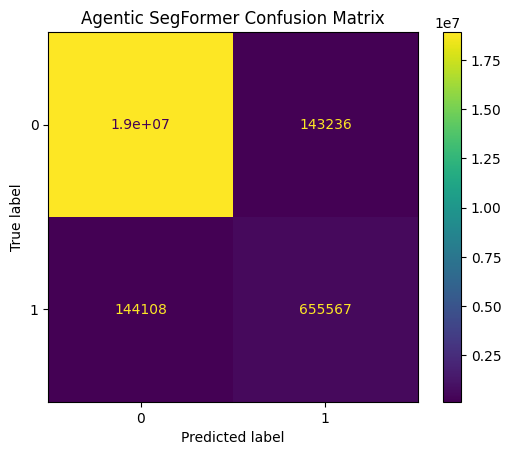

In [145]:
model.eval()

acc = 0
prec = 0
rec = 0

f1_total = 0
dice_total = 0
iou_total = 0

count = 0

all_preds = []
all_targets = []

for images, masks in test_loader:

    images = images.to(device)

    masks = masks.to(device)

    with torch.no_grad():

        pred = model(images)

        a,p,r,f1,d,i = calculate_all_metrics(

            pred,

            masks

        )

        acc += a
        prec += p
        rec += r

        f1_total += f1
        dice_total += d
        iou_total += i

        count += 1

        pred_bin = (

            torch.sigmoid(pred)

            > 0.5

        ).cpu().numpy().flatten()

        target_bin = masks.cpu().numpy().flatten()

        all_preds.extend(

            pred_bin

        )

        all_targets.extend(

            target_bin

        )

print("\nFINAL TEST RESULTS\n")

print("Test Accuracy :", acc/count)

print("Test Precision:", prec/count)

print("Test Recall   :", rec/count)

print("Test F1 Score :", f1_total/count)

print("Test Dice     :", dice_total/count)

print("Test IoU      :", iou_total/count)

cm = confusion_matrix(

    all_targets,

    all_preds

)

ConfusionMatrixDisplay(

    cm

).plot()

plt.title(

    "Agentic SegFormer Confusion Matrix"

)

plt.show()

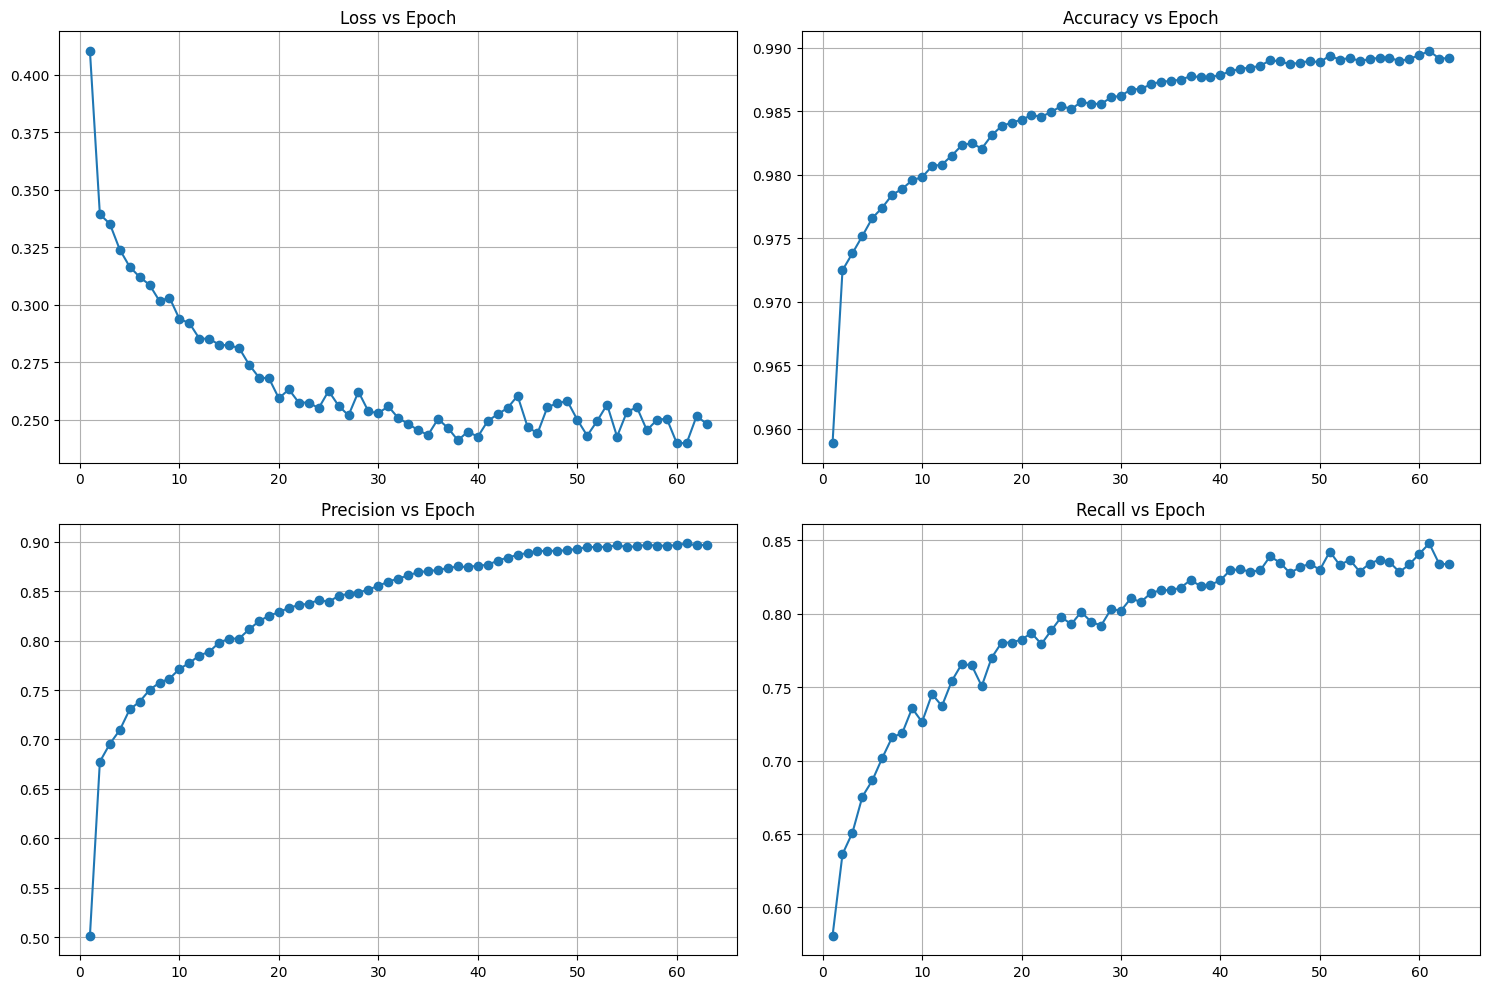

In [146]:
epochs_range = range(

    1,

    len(train_losses)+1

)

plt.figure(figsize=(15,10))

# ================= LOSS =================

plt.subplot(2,2,1)

plt.plot(

    epochs_range,

    train_losses,

    marker='o'

)

plt.title(

    "Loss vs Epoch"

)

plt.grid()

# ================= ACCURACY =================

plt.subplot(2,2,2)

plt.plot(

    epochs_range,

    train_acc,

    marker='o'

)

plt.title(

    "Accuracy vs Epoch"

)

plt.grid()

# ================= PRECISION =================

plt.subplot(2,2,3)

plt.plot(

    epochs_range,

    train_prec,

    marker='o'

)

plt.title(

    "Precision vs Epoch"

)

plt.grid()

# ================= RECALL =================

plt.subplot(2,2,4)

plt.plot(

    epochs_range,

    train_rec,

    marker='o'

)

plt.title(

    "Recall vs Epoch"

)

plt.grid()

plt.tight_layout()

plt.show()

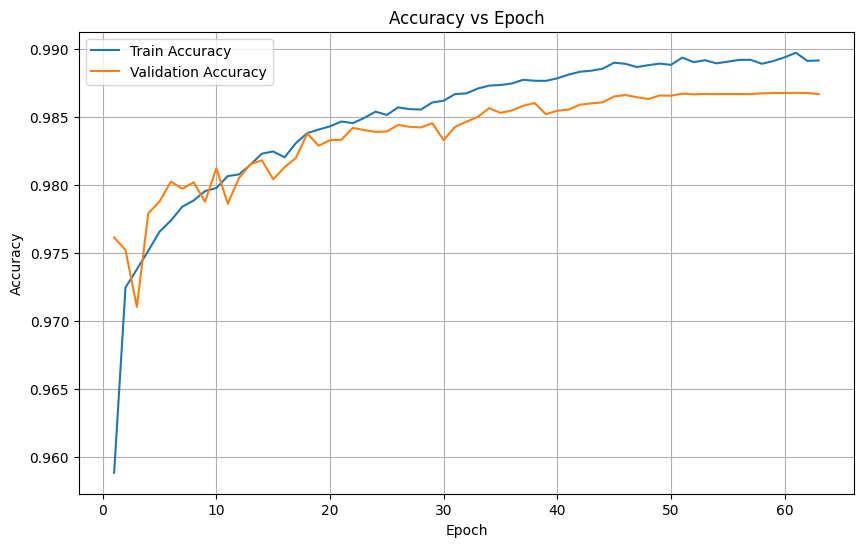

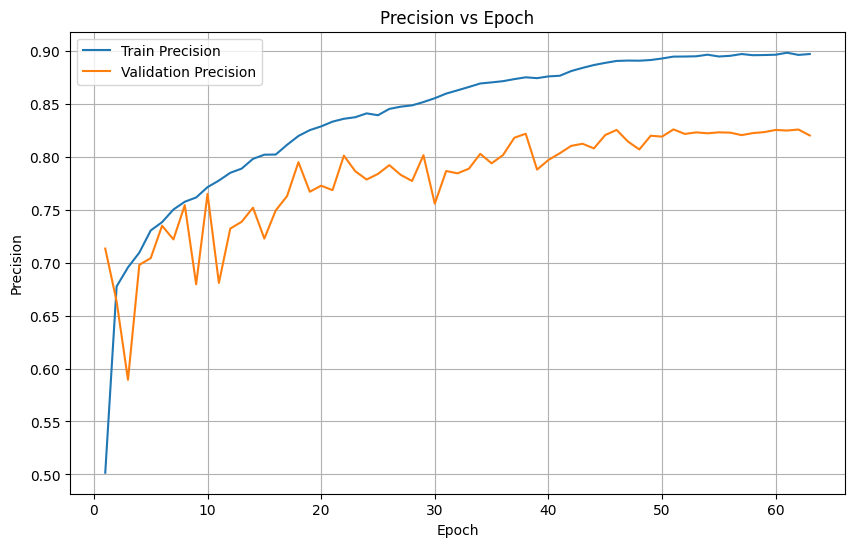

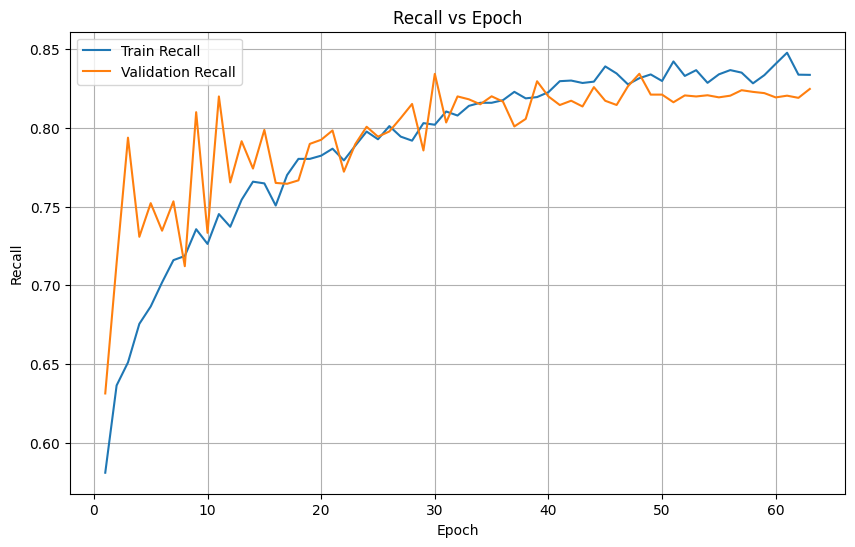

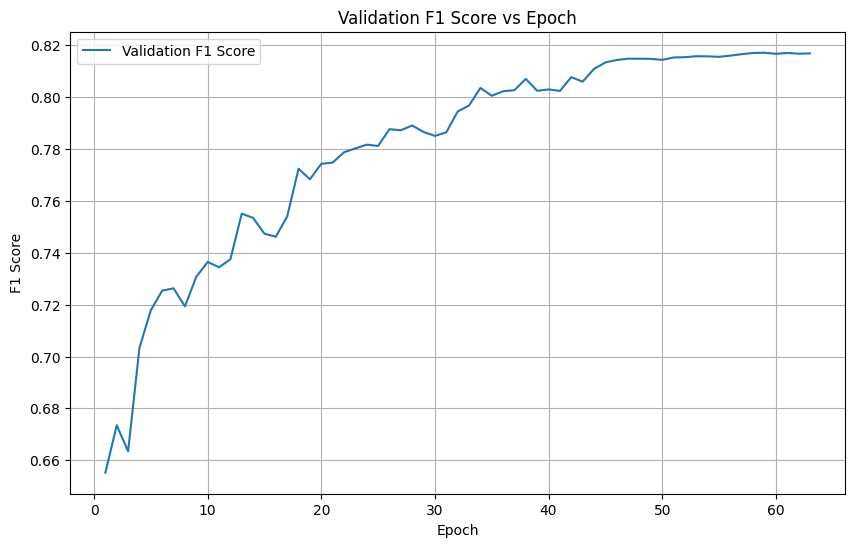

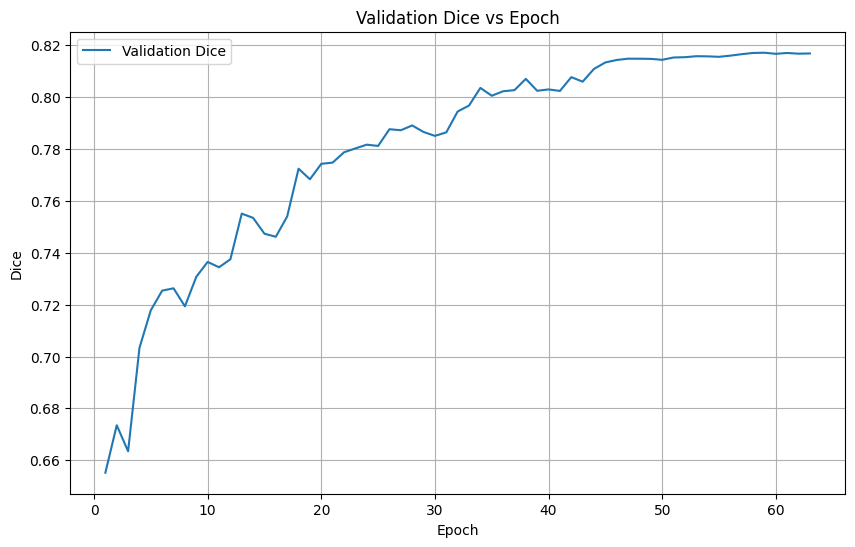

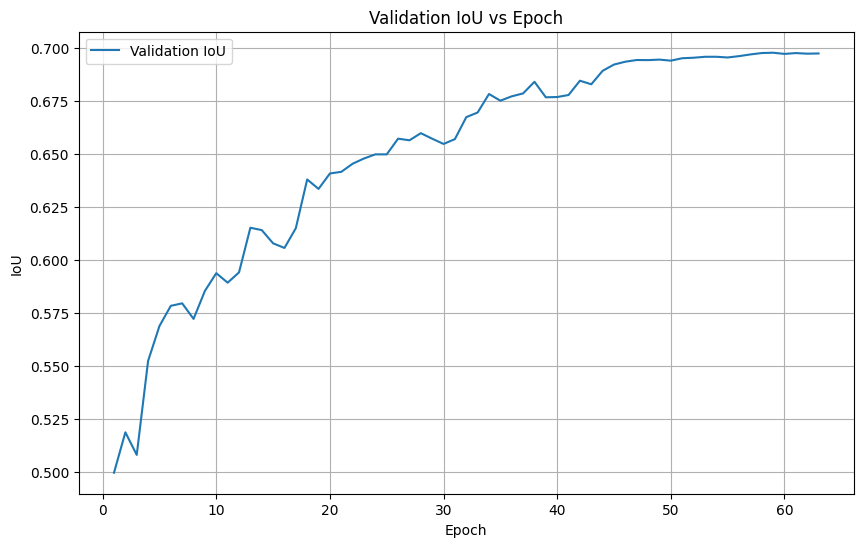

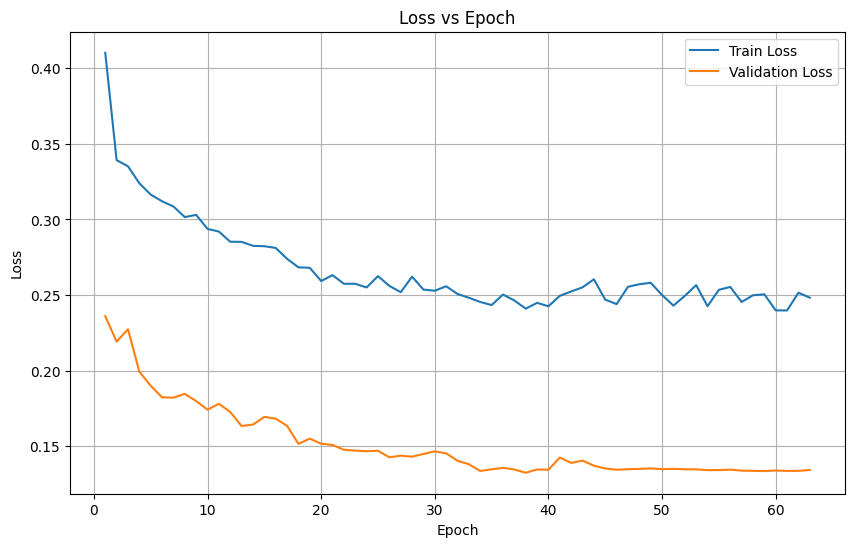

In [147]:
import matplotlib.pyplot as plt

epochs_range = range(

    1,

    len(train_acc) + 1

)

# ==========================================
# ACCURACY
# ==========================================

plt.figure(figsize=(10,6))

plt.plot(

    epochs_range,

    train_acc,

    label="Train Accuracy"

)

plt.plot(

    epochs_range,

    val_acc,

    label="Validation Accuracy"

)

plt.title("Accuracy vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

# ==========================================
# PRECISION
# ==========================================

plt.figure(figsize=(10,6))

plt.plot(

    epochs_range,

    train_prec,

    label="Train Precision"

)

plt.plot(

    epochs_range,

    val_prec,

    label="Validation Precision"

)

plt.title("Precision vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Precision")

plt.legend()

plt.grid(True)

plt.show()

# ==========================================
# RECALL
# ==========================================

plt.figure(figsize=(10,6))

plt.plot(

    epochs_range,

    train_rec,

    label="Train Recall"

)

plt.plot(

    epochs_range,

    val_rec,

    label="Validation Recall"

)

plt.title("Recall vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Recall")

plt.legend()

plt.grid(True)

plt.show()

# ==========================================
# VALIDATION F1 SCORE
# ==========================================

plt.figure(figsize=(10,6))

plt.plot(

    epochs_range,

    val_f1,

    label="Validation F1 Score"

)

plt.title("Validation F1 Score vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("F1 Score")

plt.legend()

plt.grid(True)

plt.show()

# ==========================================
# VALIDATION DICE
# ==========================================

plt.figure(figsize=(10,6))

plt.plot(

    epochs_range,

    val_dice,

    label="Validation Dice"

)

plt.title("Validation Dice vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Dice")

plt.legend()

plt.grid(True)

plt.show()

# ==========================================
# VALIDATION IoU
# ==========================================

plt.figure(figsize=(10,6))

plt.plot(

    epochs_range,

    val_iou,

    label="Validation IoU"

)

plt.title("Validation IoU vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("IoU")

plt.legend()

plt.grid(True)

plt.show()

# ==========================================
# LOSS
# ==========================================

plt.figure(figsize=(10,6))

plt.plot(

    epochs_range,

    train_losses,

    label="Train Loss"

)

plt.plot(

    epochs_range,

    val_losses,

    label="Validation Loss"

)

plt.title("Loss vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

## Loss Curve Analysis

### Key Observations

- Training loss decreased from **0.41 → 0.25**, indicating stable learning.
- Validation loss decreased from **0.23 → 0.13**, showing improved generalization.
- Validation loss remained consistently lower than training loss.
- No significant divergence was observed between training and validation curves.
- Accuracy, Precision, and Recall improved steadily throughout training.

### Reason for the Loss Gap

- Training data used **data augmentation**, making training samples more challenging.
- **Dropout regularization** was active during training and disabled during validation.
- Validation data was evaluated on cleaner, unaugmented samples.
- Hybrid **BCE + Dice Loss** introduced additional regularization effects.

### Conclusion

- The gap between training and validation loss is expected and normal.
- The model shows **good generalization ability**.
- No evidence of severe overfitting was observed.
- The training process remained stable and converged successfully.

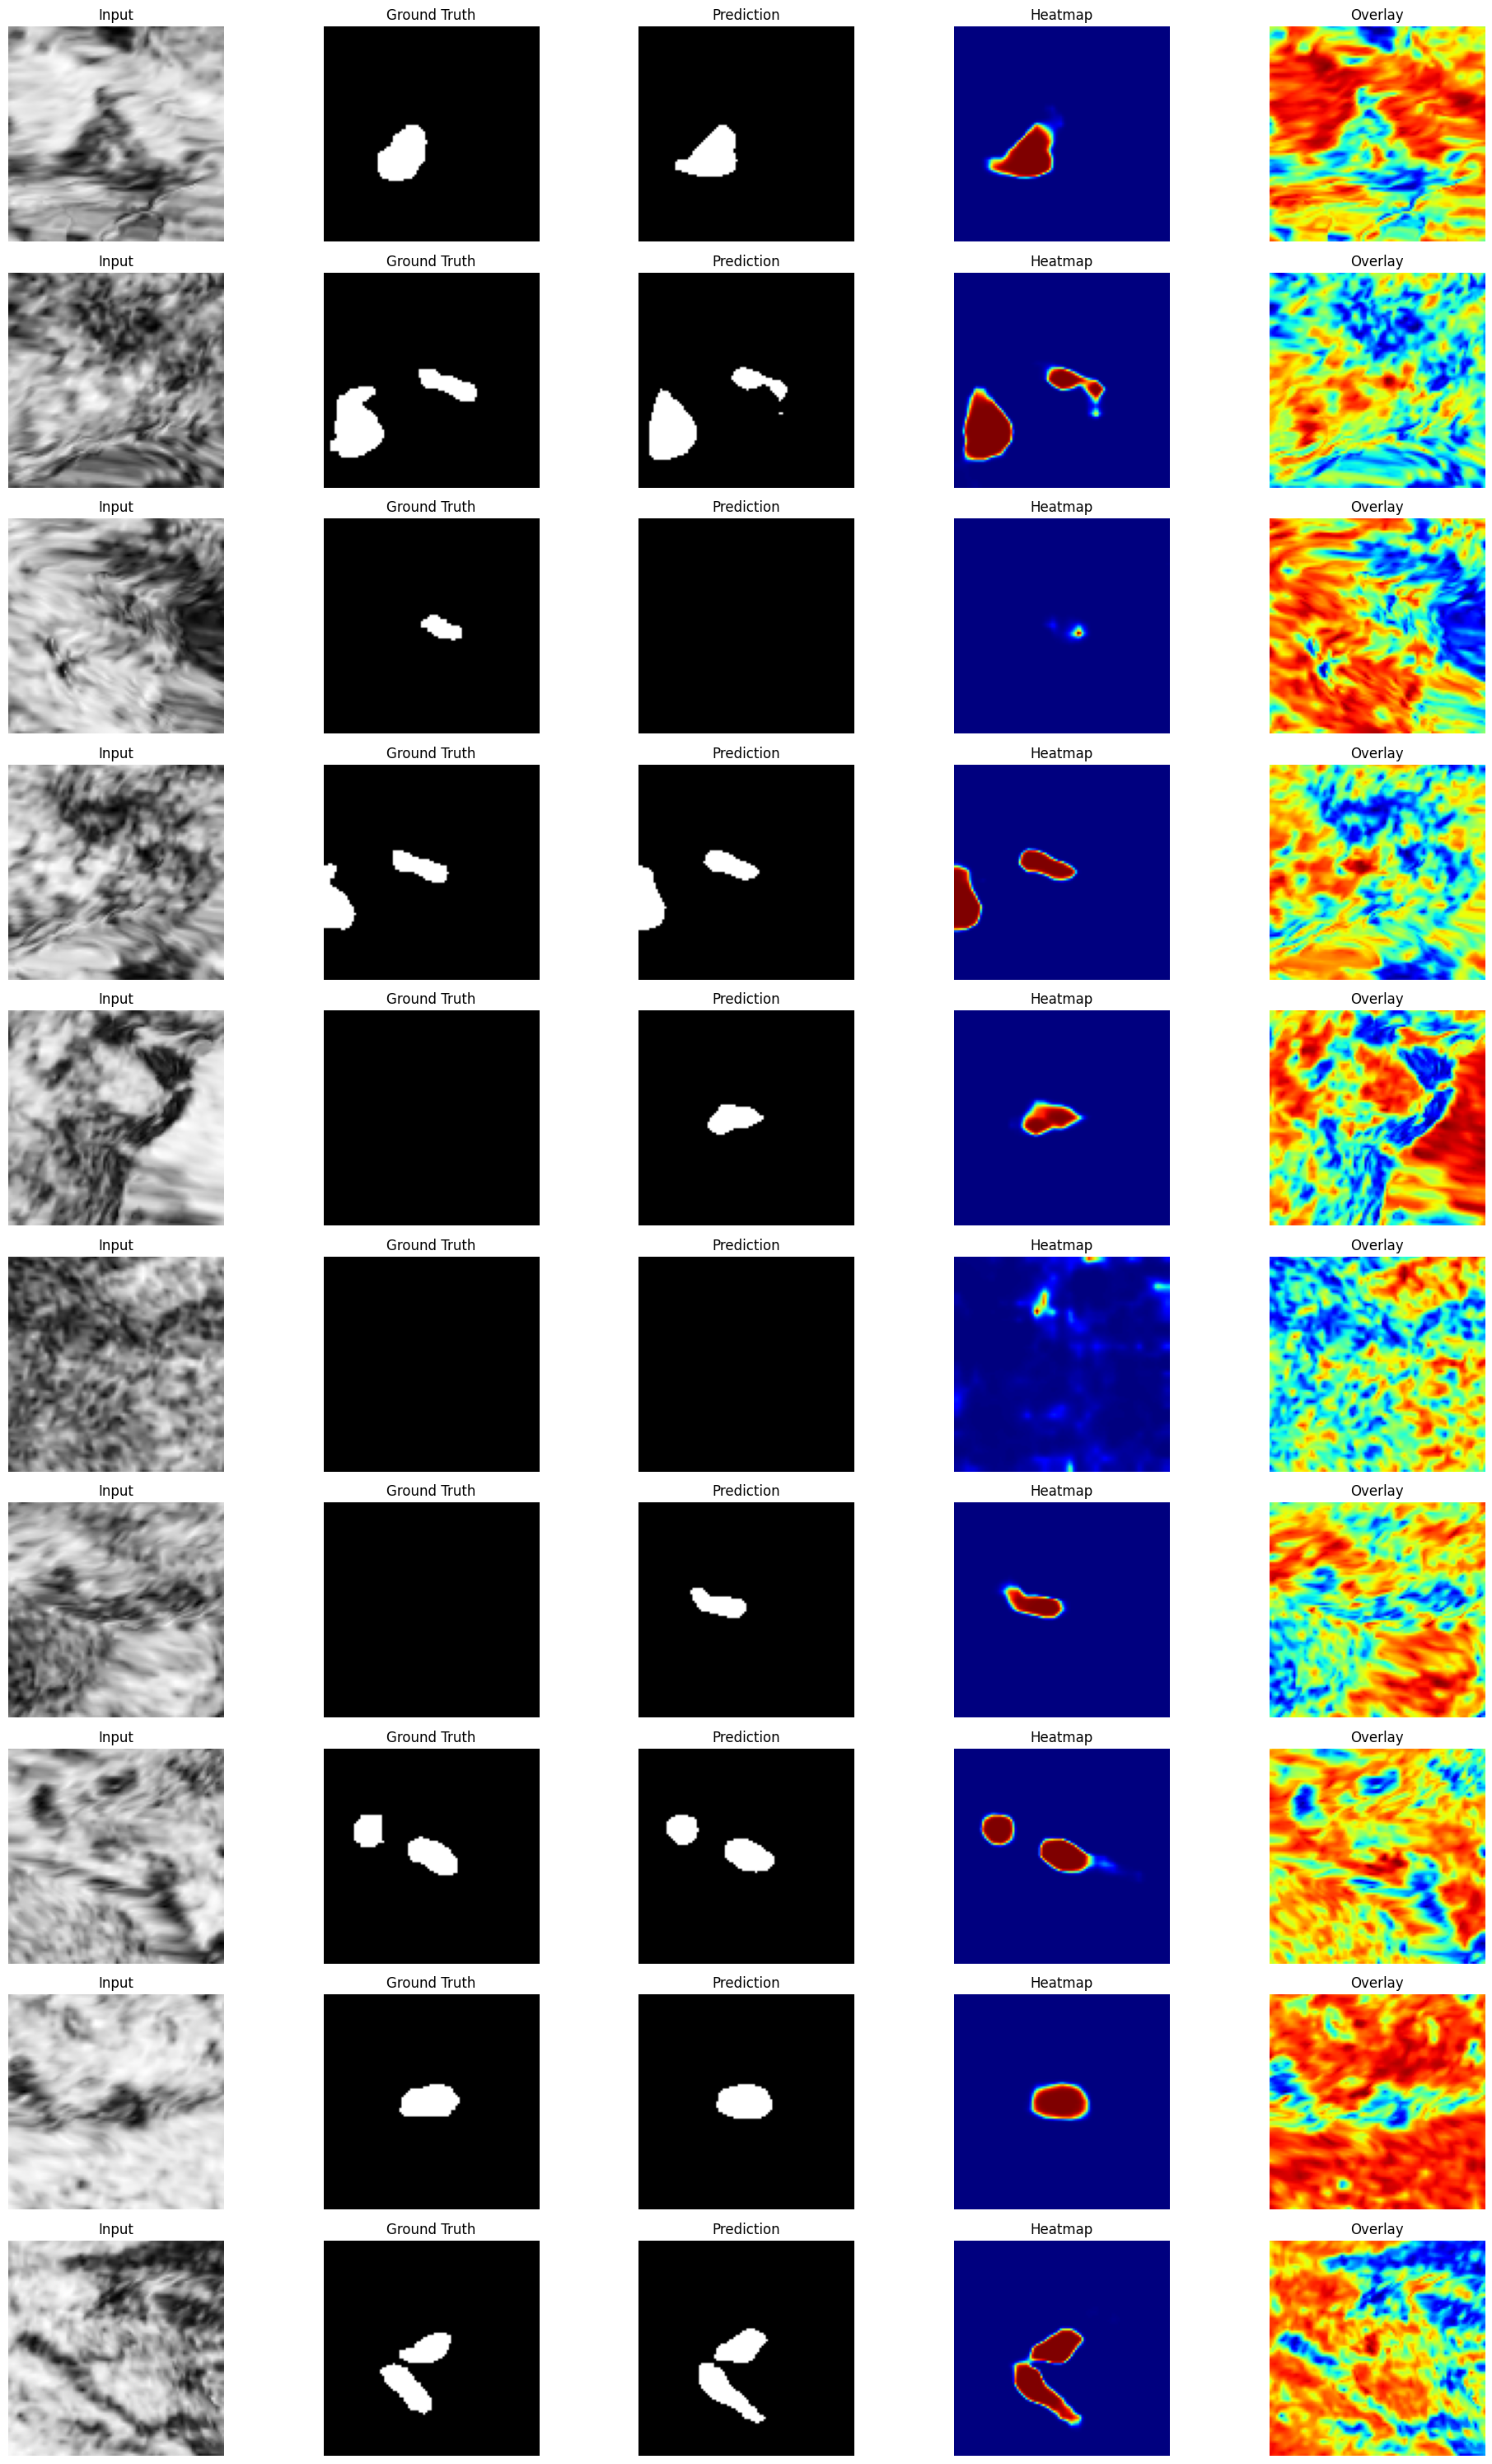

In [148]:
model.eval()

images_collected = 0

num_images = 10

all_inputs = []

all_masks = []

all_preds = []

for images, masks in test_loader:

    images = images.to(device)

    with torch.no_grad():

        pred = model(images)

        pred = torch.sigmoid(pred)

    all_inputs.extend(

        images.cpu().numpy()

    )

    all_masks.extend(

        masks.numpy()

    )

    all_preds.extend(

        pred.cpu().numpy()

    )

    images_collected += images.shape[0]

    if images_collected >= num_images:

        break

all_inputs = np.array(all_inputs)

all_masks = np.array(all_masks)

all_preds = np.array(all_preds)

plt.figure(figsize=(20,30))

for i in range(num_images):

    input_img = all_inputs[i][0]

    true_mask = all_masks[i][0]

    pred_mask = all_preds[i][0]

    binary_pred = (

        pred_mask > 0.5

    ).astype(float)

    heatmap = pred_mask

    overlay = (

        0.6 * input_img

        +

        0.4 * heatmap

    )

    # INPUT

    plt.subplot(

        num_images,

        5,

        i*5 + 1

    )

    plt.title("Input")

    plt.imshow(

        input_img,

        cmap='gray'

    )

    plt.axis('off')

    # GROUND TRUTH

    plt.subplot(

        num_images,

        5,

        i*5 + 2

    )

    plt.title("Ground Truth")

    plt.imshow(

        true_mask,

        cmap='gray'

    )

    plt.axis('off')

    # PREDICTION

    plt.subplot(

        num_images,

        5,

        i*5 + 3

    )

    plt.title("Prediction")

    plt.imshow(

        binary_pred,

        cmap='gray'

    )

    plt.axis('off')

    # HEATMAP

    plt.subplot(

        num_images,

        5,

        i*5 + 4

    )

    plt.title("Heatmap")

    plt.imshow(

        heatmap,

        cmap='jet'

    )

    plt.axis('off')

    # OVERLAY

    plt.subplot(

        num_images,

        5,

        i*5 + 5

    )

    plt.title("Overlay")

    plt.imshow(

        overlay,

        cmap='jet'

    )

    plt.axis('off')

plt.tight_layout()

plt.show()